<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day07-protein-structure-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 7 — Protein Structure in code {.unnumbered}

This notebook fetches two real crystal structures of human hemoglobin — the
deoxy ("T", tense) state `2HHB` and the oxy ("R", relaxed) state `1HHO` —
and uses them to make the four levels of protein structure, and the
sequence-to-structure prediction problem, concrete: primary structure is
just the residue list; secondary structure is independently re-derived
here with a *different* algorithm than Day 6 used, as a cross-check;
quaternary structure is measured directly as a real distance in 3D space,
and that distance is shown to actually change between the two structures —
the real geometric signature of hemoglobin's allosteric mechanism.

Structure parsing and geometry use [Biopython](https://biopython.org/)
(`Bio.PDB`); secondary-structure assignment and rendering use a locally
installed [PyMOL](https://pymol.org/) (open-source), driven headlessly
from Python via a small generated script + `subprocess`, since PyMOL's
own Python module isn't installed inside this notebook's conda
environment.

In [1]:
import subprocess
import itertools
import os
import numpy as np
from Bio.PDB import PDBList, PDBParser

PDB_IDS = ["2hhb", "1hho"]  # 2HHB = deoxy/T-state, 1HHO = oxy/R-state

pdbl = PDBList()
paths = {pdb_id: pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="pdb") for pdb_id in PDB_IDS}
paths

{'2hhb': './pdb2hhb.ent', '1hho': './pdb1hho.ent'}

## Primary and quaternary structure: what's actually in the file

Hemoglobin is a **heterotetramer**: two copies of an alpha chain and two
copies of a beta chain (the same beta chain that is this course's running
example, `HBB`, first met on Day 3). Parsing the structure and just
counting residues per chain already shows primary structure (the residue
sequence itself) and sets up quaternary structure (how many chains, and
which ones are identical).

In [2]:
parser = PDBParser(QUIET=True)
structures = {pdb_id: parser.get_structure(pdb_id, paths[pdb_id]) for pdb_id in PDB_IDS}

for pdb_id in PDB_IDS:
    print(f"--- {pdb_id.upper()} ---")
    for chain in structures[pdb_id][0]:
        protein_residues = [r for r in chain if r.id[0] == " "]
        hetero = sorted({r.get_resname() for r in chain if r.id[0] != " " and r.get_resname() != "HOH"})
        if protein_residues:
            print(f"  chain {chain.id}: {len(protein_residues)} residues, ligands={hetero}")

--- 2HHB ---
  chain A: 141 residues, ligands=['HEM']
  chain B: 146 residues, ligands=['HEM', 'PO4']
  chain C: 141 residues, ligands=['HEM']
  chain D: 146 residues, ligands=['HEM', 'PO4']
--- 1HHO ---
  chain A: 141 residues, ligands=['HEM', 'OXY', 'PO4']
  chain B: 146 residues, ligands=['HEM', 'OXY']


`2HHB` has all four chains (A, B, C, D) in the file directly. `1HHO`'s
file only contains one alpha/beta pair (A, B) — the crystal's asymmetric
unit — plus a `REMARK 350` symmetry record that generates the other half
of the biological tetramer. That is exactly what a **rigid-body
transformation** (a rotation + translation, no shape change) is for, and
it matters again below when measuring a quaternary distance in `1HHO`.

Both structures agree: two 141-residue alpha chains, two 146-residue beta
chains, each carrying one heme group (`HEM`) — consistent with the real
human alpha- and beta-globin sequences.

## Secondary structure: an independent cross-check of Day 6's number

Day 6 fetched `HBB`'s secondary-structure breakdown live from EBI's PDBe
API and reported 117 of 147 residues (about 80%) in one of 12 alpha
helices, with zero beta strands. Here, the *same* question is answered a
completely different way: PyMOL's own built-in secondary-structure
assignment algorithm (`dss`, run headlessly here, not the PDBe API) is
applied directly to `2HHB`'s beta chain.

In [3]:
pymol_ss_script = '''
from pymol import cmd

cmd.load("PDBPATH", "hb")
cmd.dss("hb")

ss_list = []
cmd.iterate("hb and chain B and polymer and name CA",
            "ss_list.append(ss)", space={"ss_list": ss_list})

total = len(ss_list)
helix = sum(1 for s in ss_list if s == "H")
strand = sum(1 for s in ss_list if s == "S")
print("TOTAL", total)
print("HELIX", helix)
print("STRAND", strand)
print("PCT_HELIX", round(100 * helix / total, 1))
'''.replace("PDBPATH", paths["2hhb"])

with open("_day07_pymol_ss.py", "w") as f:
    f.write(pymol_ss_script)

# PyMOL's launcher script re-invokes "python3" from PATH to find its own
# module; prepend /usr/bin so it finds the system Python that has PyMOL
# installed, not this notebook's conda environment.
pymol_env = dict(os.environ)
pymol_env["PATH"] = "/usr/bin:/bin:" + pymol_env.get("PATH", "")

result = subprocess.run(["/usr/bin/pymol", "-cq", "_day07_pymol_ss.py"],
                         capture_output=True, text=True, env=pymol_env)
for line in result.stdout.splitlines():
    if line.startswith(("TOTAL", "HELIX", "STRAND", "PCT_HELIX")):
        print(line)

TOTAL 146
HELIX 118
STRAND 0
PCT_HELIX 80.8


PyMOL's `dss` finds **118 of 146 residues (80.8%) in a helix and 0 in a
strand** — a different algorithm, run on the coordinates directly rather
than through PDBe's own annotation pipeline, and it lands on essentially
the same answer as Day 6's number (117/147, ≈80%, 0 strands). The
one-residue difference is just where the two algorithms draw a helix
boundary at its edges — both agree HBB is an almost purely alpha-helical
protein with no beta content at all, now confirmed two independent
ways.

## Rendering the tertiary/quaternary structure

The same headless-PyMOL approach can render an actual image of the
tetramer: cartoon representation (so alpha helices are visible directly,
matching the `dss` numbers above), one color per chain, and the four heme
iron atoms shown as spheres.

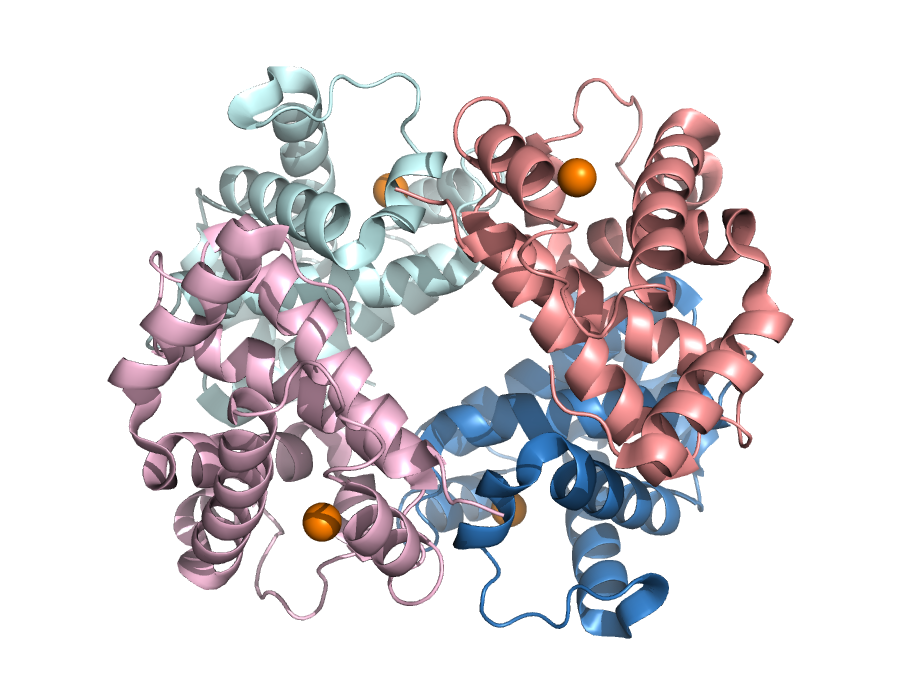

In [4]:
pymol_render_script = '''
from pymol import cmd

cmd.load("PDBPATH", "hb")
cmd.hide("everything")
cmd.show("cartoon", "polymer")
cmd.show("spheres", "resn HEM and name FE")
cmd.color("skyblue", "chain A")
cmd.color("salmon", "chain B")
cmd.color("palecyan", "chain C")
cmd.color("lightpink", "chain D")
cmd.color("orange", "resn HEM and name FE")
cmd.bg_color("white")
cmd.set("ray_opaque_background", 0)
cmd.orient("polymer")
cmd.ray(900, 700)
cmd.png("_day07_2hhb_render.png", dpi=150)
'''.replace("PDBPATH", paths["2hhb"])

with open("_day07_pymol_render.py", "w") as f:
    f.write(pymol_render_script)

subprocess.run(["/usr/bin/pymol", "-cq", "_day07_pymol_render.py"],
                capture_output=True, text=True, env=pymol_env)

from IPython.display import Image
Image("_day07_2hhb_render.png")

Two alpha chains (blue/cyan), two beta chains (salmon/pink), all four
almost entirely built from alpha helices — exactly what the `dss` numbers
above said — arranged around each other with four heme groups (orange
spheres) roughly at the corners. That spatial arrangement of four folded
chains with respect to each other **is** quaternary structure.

## Measuring a real quaternary-structure distance

A concrete geometric property, rather than just a picture: the distance
between the iron atoms of the two **beta**-chain hemes. This exact
distance is the classic textbook signature of hemoglobin's allosteric
mechanism (Baldwin & Chothia, 1979) — it should be larger in the
deoxygenated ("T", tense) state than in the oxygenated ("R", relaxed)
state, since the whole point of the T→R quaternary shift is that the two
beta chains move closer together as oxygen binds.

First, all six pairwise Fe–Fe distances within `2HHB` (T-state), which is
small enough to have all four chains directly in one file:

In [5]:
fe_2hhb = {}
for chain in structures["2hhb"][0]:
    for res in chain:
        if res.get_resname() == "HEM":
            fe_2hhb[chain.id] = res["FE"].get_coord()

print("2HHB (deoxy, T-state) pairwise Fe-Fe distances:")
for a, b in itertools.combinations(sorted(fe_2hhb), 2):
    d = np.linalg.norm(fe_2hhb[a] - fe_2hhb[b])
    print(f"  {a}-{b}: {d:.2f} A")

beta_beta_T = np.linalg.norm(fe_2hhb["B"] - fe_2hhb["D"])
print(f"\nBeta-beta Fe-Fe distance, T-state (2HHB): {beta_beta_T:.2f} A")

2HHB (deoxy, T-state) pairwise Fe-Fe distances:
  A-B: 36.49 A
  A-C: 34.16 A
  A-D: 24.35 A
  B-C: 24.26 A
  B-D: 39.51 A
  C-D: 36.42 A

Beta-beta Fe-Fe distance, T-state (2HHB): 39.51 A


`1HHO`'s file only has one alpha/beta pair, so getting the *other* beta
chain means actually applying the rigid-body transformation from the
file's `REMARK 350` record — the same kind of operation, in miniature,
that structure-comparison tools like RMSD or TM-align (mentioned on the
book page) use to superimpose whole structures onto each other.

In [6]:
fe_1hho = {}
for chain in structures["1hho"][0]:
    for res in chain:
        if res.get_resname() == "HEM":
            fe_1hho[chain.id] = res["FE"].get_coord()

# REMARK 350 BIOMT for the second copy in 1HHO's biological tetramer:
# swap x and y, negate z, no translation.
R = np.array([[0, 1, 0],
              [1, 0, 0],
              [0, 0, -1]])

fe_B = np.array(fe_1hho["B"], dtype=float)
fe_B_symmetry_mate = R @ fe_B

beta_beta_R = np.linalg.norm(fe_B - fe_B_symmetry_mate)
print(f"Beta-beta Fe-Fe distance, R-state (1HHO): {beta_beta_R:.2f} A")
print(f"Beta-beta Fe-Fe distance, T-state (2HHB): {beta_beta_T:.2f} A")
print(f"Contraction going deoxy (T) -> oxy (R):    {beta_beta_T - beta_beta_R:.2f} A")

Beta-beta Fe-Fe distance, R-state (1HHO): 34.62 A
Beta-beta Fe-Fe distance, T-state (2HHB): 39.51 A
Contraction going deoxy (T) -> oxy (R):    4.89 A


Two independently solved crystal structures of the same protein, in its
two functional states, show the two beta hemes roughly **5 &#8491; closer
together** in the oxygenated state than in the deoxygenated one — a real,
measured instance of the T&#8594;R quaternary transition, not just a
textbook diagram. This is also exactly the kind of number a quaternary
structure-comparison metric (Ligand RMSD, interface RMSD, ...) is built
to summarize systematically across many structures at once, rather than
one hand-picked distance at a time.

## Try it yourself

Some things to change and re-run:

- Measure the **alpha-alpha** Fe-Fe distance instead (`fe_2hhb["A"]` vs
  `fe_2hhb["C"]`) — does it also change between the two states, and if
  so, by how much compared to the beta-beta distance?
- Fetch a different pair of PDB entries for the same T/R comparison —
  try `2hhb` (T) against `1bbb` (R) instead of `1hho`, and see whether
  the beta-beta contraction is consistent.
- Change the PyMOL render script above to color by secondary structure
  (`cmd.color("red", "ss H")`, `cmd.color("yellow", "ss S")`) instead of
  by chain, to see the helices highlighted directly on the structure.

In [7]:
for f in ["_day07_pymol_ss.py", "_day07_pymol_render.py", "_day07_2hhb_render.png"]:
    if os.path.exists(f):
        os.remove(f)

(Scratch files PyMOL/this notebook wrote to disk are cleaned up above; the downloaded `.ent` PDB files are left in place so re-running the notebook doesn't re-download them.)